# "Exploring the Correlation Between GNI and the use of renewable energy"
by group 22:
- Alessandro Dell'Orto
- Other collaborator
- Other collaborator



# Section 1: Introduction


## Problem statement
The 2030 Agenda for Sustainable Development, adopted by all United Nations Member States in 2015, provides a shared blueprint for peace and prosperity for people and the planet, now and into the future.

Some of these objectives are often said to conflict with each other, requiring coordination from countries and institutions. For example, some argue that the green energy transition (part of Objective 7) could impede economic growth (Objective 8), particularly for developing countries.

Our analysis aims to assess whether there is a correlation between the share of renewable energy consumption and a country’s average income, if the trends of these indexes have followed similar trajectories over the past few decades, how the overall situation has changed between 1990 and 2022 and how can we expect the situation to evolve in the future.

## Assumptions

The GNI is a good measure for the standard of living of the inhabitants of that country. This measure also indicates the means and ability of those countries to invest in renewable and sustainable energy sources. From this we can see whether rich countries actually invest a higher percentage of their money in sustainability energy sources than their less affluent counterparts. This will be a good measure to see if sustainability is a priority of a nation.

## Research questions

- How does the consumption of renewable energy relate to the Gross National Income (GNI) per capita across different countries?

- How have the two indexes evolved over the last 32 years and how similar are the trajectories?

- Are there still countries that have no share of renewables in their energy consumption and, if so, are they decreasing in number?

- What are the countries that have the highest share of energy consumption coming from renewables and how high is their GNI?

- Regarding areas with lower GNI, how can we expect their situation to vary in the future for both indexes?

- Is the GNI per capita of the country a good estimator for predicting the percentage of renewable energy consumption of a country?

## Method

The analysis will be performed by data visualization for the current (2022) and past situation. Predictions will be made using the Machine Learning (ML) technique of linear regression. 

# Section 2: Datasets

Two datasets have been used to perform both the analysis and the predictions:

## Dataset 1
**Index name:** Renewable energy consumption

**Source:** World Bank (https://data.worldbank.org/indicator/EG.FEC.RNEW.ZS)

**Unit:** % of total final energy consumption

**Period:** 1990-2022

**Geography** Country or region


## Dataset 2
**Index name:** Gross national income (GNI) per capita

**Source:** Our World in Data (https://ourworldindata.org/grapher/gross-national-income-per-capita-undp)

**Description:** Gross national income (GNI) measures the total income earned by residents of a country, including income earned abroad. This
data is adjusted for inflation and differences in the cost of living between countries.

**Unit:** international-$ in 2017 prices


**Period:** 1990-2022

**Geography:** Country or region

# Section 3: Preprocessing



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Since the datasets come from two different sources, and since some data is incomplete for some countries, a cleaning and matching process has to be performed:


## Dataset 1

**Step 1:** Data is acquired properly by skipping the first 4 rows

**Setp 2:** The .cvs file has columns for years from 1960 to 2023 even if no data is available for 1960 to 1989 and 2023. All those columns can be dropped

**Step 3:** Some countries (six) have no entry for any year. Those countries can be dropped.

**Step 4:** Some countries have empty entries for some years. Since entries are given year-by-year, filling can be done via linear interpolation assuming a gradual change in time. Data is also missing in starting or ending years, so forward and backward filling was also applied.

**Step 5:** Columns "Indicator name" and "Indicator Code" have no use for this analysis so they can be dropped.

**Step 6:** "Country Name" column name has been changed with "Country" for simplicity.


In [2]:

### DATASET 1 ###

#STEP 1 - Load .csv and skip first 4 rows
df1_raw = pd.read_csv('renewable-energy-consumption.csv', skiprows = 4)

#STEP 2 - Drop all empty columns
df1_clean_column = df1_raw.dropna(axis = 1, how = 'all')

#STEP 3 - Drop rows with no year entry 
#Name and code entries are still present, so drop all rows with less than 5 non-NaN values
df1_clean_rows = df1_clean_column.dropna (axis = 0, thresh=5)

#STEP 4 - Filling
#Some entries have "None" value, change those to NaN
df1_clean_rows = df1_clean_rows.replace({None: np.nan}).copy()

# Convert relevant columns to float type explicitly
years1 = list(map(str, range(1990, 2023)))
df1_clean_rows[years1] = df1_clean_rows[years1].astype(float)

# Apply interpolation for years in between
df1_clean_rows[years1] = df1_clean_rows[years1].interpolate(method='linear', axis=1)
# Apply forward filling for most recent years
df1_clean_rows[years1] = df1_clean_rows[years1].ffill(axis=1)
# Apply backward filling for least recent years
df1_clean_rows[years1] = df1_clean_rows[years1].bfill(axis=1)

#STEP 5 - Drop code columns
df1_new = df1_clean_rows.drop(columns=['Indicator Name', 'Indicator Code'])

#Step 6 - Change Country column label
df1 = df1_new.rename(columns={"Country Name":"Country"})


## Dataset 2

**Step 1:** Data is acquired properly as it is

**Setp 2:** The acquired dataframe has years as a column entry. In order to make it compatible with the other dataframe we firstly transformed it into a pivot table with "Year" as column parameter.

**Step 3:** Data goes from 1990 to 2022 and all year has data for most countries, so no year column has to be dropped.

**Step 4:** All countries have data for at least 15 years. So no country has been dropped.

**Step 5:** The pivot table is brought back to a dataframe format which is now coherent with the other dataframe.

In [3]:

### DATASET 2 ###

#Step 1 - Load .csv
df2_raw = pd.read_csv ("gross-national-income-per-capita-undp.csv")

#Step 2 - Make Dataframe 2 as pivot table with "Year" as column values
pivot_df2 = df2_raw.pivot_table(index='Entity', columns='Year', values='Gross national income per capita')

#Steps 3 & 4 - Cheack that no rows and columns have to be dropped
print(pivot_df2.count(axis=1).min(),pivot_df2.count(axis=0).min())



15 194


In [4]:
#Step 5 - Bring pivot table back to (Now correct) DataFrame format
df2 = pivot_df2.reset_index().rename(columns={"Entity":"Country"})  #Give same label to Country column
df2.columns.name = None   #Otherwise the column names row would be called "Year"
#df2

years2 = list(range(1990,2023))
df2[years2] = df2[years2].interpolate(method='linear', axis=1)
df2[years2] = df2[years2].ffill(axis=1)
df2[years2] = df2[years2].bfill(axis=1)

## Matching country names

**Step 1:** In Dataframe 1, some countries have articles or denominations after the main name (e.g "Gambia, the"). The most simplistic solution is to split the string before the comma and drop the rest.

**Setp 2:** In Dataframe 2, some regions or countries have additional information between brackets (e.g. "Micronesia (country)" or "Arab States (UNPD)"). The most simplistic solution is to split the string before the opening bracket and drop the rest.

**Step 3:** Make a Pandas series of the country names that match between the two dataframes.

**Step 4:** Check all country names present in Dataframes 1 and 2 that are not in the pd-series. Some are countries or regions that are actually absent in the other Dataframe, others (about 20) just have slight differences in the names. The only solution here is to change those manually.
(NOTE: with step 1, "Congo" and "Democratic rebublic of Congo" were both named "Congo" in df1. The latter was changed manually to match the correct name given in df2) 

**Step 5:** Update the pd-series and drop all rows in Dataframes 1 and 2 which country name is not in the pd-series.

**Step 6:** Update the dataframes in order to contain only the shared countries and sort them alphabetically so that they both share the same order. 

Now the data is ready for visualization processes.

In [5]:

### MATCHING COUNTRY NAMES ###

#Step 1 - Remove text after the commas from Dataframe 1
df1.loc[:, "Country"] = df1['Country'].str.split(',').str[0]

#Step 2 - Remove information between brackets from Dataframe 2
df2.loc[:, "Country"] = df2['Country'].str.split('(').str[0]

#Step 3 - Make pd-series of shared country names
present_countries = df1.loc[df1['Country'].isin(df2['Country']), 'Country']

#Currently the pd-series has 176 entries
print(present_countries.size)

176


In [6]:
#Step 4.1 - Check countries in Dataframe 1 not in the pd-series (remove commenting to check)
#df1.loc[~df1['Country'].isin(present_countries), 'Country'].unique()

In [7]:
#Step 4.2 - Check countries in Dataframe 2 not in the pd-series (remove commenting to check)
#df2.loc[~df2['Country'].isin(present_countries), 'Country'].unique()

In [8]:
#Step 4.3 - Fix country names manually
df1.loc[df1['Country'] == 'Brunei Darussalam', 'Country'] = 'Brunei'
df1.loc[df1['Country'] == 'Cabo Verde', 'Country'] = 'Cape Verde'
df1.loc[df1['Country'] == 'Arab World', 'Country'] = 'Arab States '
df1.loc[df1['Country'] == 'East Asia & Pacific', 'Country'] = 'East Asia and the Pacific '
df1.loc[df1['Country'] == 'Timor-Leste', 'Country'] = 'East Timor'
df1.loc[df1['Country'] == 'Hong Kong SAR', 'Country'] = 'Hong Kong'
df1.loc[df1['Country'] == 'Kyrgyz Republic', 'Country'] = 'Kyrgyzstan'
df1.loc[df1['Country'] == 'Lao PDR', 'Country'] = 'Laos'
df1.loc[df1['Country'] == 'Latin America & Caribbean', 'Country'] = 'Latin America and the Caribbean '
df1.loc[df1['Country'] == 'West Bank and Gaza', 'Country'] = 'Palestine'
df1.loc[df1['Country'] == 'Russian Federation', 'Country'] = 'Russia'
df1.loc[df1['Country'] == 'St. Kitts and Nevis', 'Country'] = 'Saint Kitts and Nevis'
df1.loc[df1['Country'] == 'St. Vincent and the Grenadines', 'Country'] = 'Saint Vincent and the Grenadines'
df1.loc[df1['Country'] == 'St. Lucia', 'Country'] = 'Saint Lucia'
df1.loc[df1['Country'] == 'Slovak Republic', 'Country'] = 'Slovakia'
df1.loc[df1['Country'] == 'Syrian Arab Republic', 'Country'] = 'Syria'
df1.loc[df1['Country'] == 'Turkiye', 'Country'] = 'Turkey'
df1.loc[df1['Country'] == 'Viet Nam', 'Country'] = 'Vietnam'

#Step 4.4 - correct inaccurancy with Democratic Republic of Congo
df1.loc[df1["Country Code"]=="COD","Country"] = "Democratic Republic of Congo"

In [9]:
#Step 5 - Update pd-series of shared countries
present_countries = df1.loc[df1['Country'].isin(df2['Country']), 'Country']
#Now the pd-series has 194 entries
print(present_countries.size)

194


In [10]:
#Step 6 - Remove all non-shared countries and sort dataframes alfabethically
df1 = df1.loc[df1["Country"].isin(present_countries), :].sort_values(by="Country")
df2 = df2.loc[df2["Country"].isin(present_countries), :].sort_values(by="Country")

# Section 4: Exploration

Before delving into data visualization, it is useful to take a look at data to decide the most efficient and useful way to gain insight from it.
A rough analysis of mean, median, highest and lowest values was performed for both dataframes.

## Mean and median values

### Dataset 1

First thing to notice is that the mean or median values are not indicative for Dataset 1, as the percentage of each country doesn't take into consideration the country size, population, or total energy consumption.

Indeed, both the mean and the median drop over the years.

The best choice here is to use the data coming from "World". In fact, the percentages are significantly lower and raise over the years.

In [11]:
mean_df1= df1[years1].mean() #Mean values per year
median_df1 = df1[years1].median() #Median values per year
world_df1 = df1.loc[df1["Country"]=="World",years1].squeeze() #World index per year

#Build a dataframe with the three Series to compare them
summary_df1 = pd.DataFrame({
    'Mean % energy consumption': mean_df1,
    'Median % energy consumption': median_df1,
    'World % energy consumption': world_df1
})

#Print the dataframe
print('\n\t\t  Summary Statistics Renewable Energy Each Year (1990-2022)\n')
summary_df1


		  Summary Statistics Renewable Energy Each Year (1990-2022)



,Mean % energy consumption,Median % energy consumption,World % energy consumption
1990,36.143863,25.966495,16.662330
1991,36.171760,26.950000,16.821274
1992,36.242637,26.250000,17.165780
1993,36.303197,27.100000,17.209889
1994,36.253562,29.200000,17.354901
1995,36.096413,30.291376,17.426007
1996,35.719744,29.441429,17.443663
1997,35.327193,28.172595,17.472866
1998,35.036248,27.450000,17.631283
1999,34.938997,27.050000,17.879820


### Dataset 2

Here the mean and median values work better, because GNI is given per capita. However, world index is still preferable as it's more precise:

In [12]:
mean_df2= df2[years2].mean() #Mean values per year
median_df2 = df2[years2].median() #Median values per year
world_df2 = df2.loc[df2["Country"]=="World",years2].squeeze() #World index per year

#Build a dataframe with the three Series to compare them
#Displayed data is brought to int format to make it cleaner
summary_df2 = pd.DataFrame({
    'Mean GNI per capita': mean_df2.astype(int),
    'Median GNI per capita': median_df2.astype(int),
    'World GNI per capita': world_df2.astype(int)
})

#Print the dataframe
print('\n\t    Summary Statistics GNI per capita (1990-2022)\n')
summary_df2


	    Summary Statistics GNI per capita (1990-2022)



,Mean GNI per capita,Median GNI per capita,World GNI per capita
1990,13042,7241,9678
1991,12924,7405,9623
1992,12919,7623,9609
1993,12945,7484,9620
1994,13104,6470,9729
1995,13404,6773,9893
1996,13718,6961,10124
1997,14236,7176,10379
1998,14540,7315,10480
1999,14733,7636,10688


## Top and worst performing countries

### Dataset 1

It's useful to see which countries have highest and worst performance each year. However, there is more than one country that performs lowest each year (always at 0%)

In [13]:

#Find the name of best performing county
top_df1_country = df1.set_index("Country")[years1].idxmax()
#Find the coresponding entry for each year
top_df1_values = df1[years1].max()

#Find the name of worst performing county
low_df1_country = df1.set_index("Country")[years1].idxmin()
#Find the coresponding entry for each year
low_df1_values = df1[years1].min()

#Build a dataframe with the four Series
top_low_df1 = pd.DataFrame({
    'MAX - Country': top_df1_country,
    'MAX - %': top_df1_values,
    'MIN - Country': low_df1_country,
    'MIN - %': low_df1_values,
})

#Print the dataframe
print('\n     Best and worst performers in renewable energy consumption\n')
top_low_df1


     Best and worst performers in renewable energy consumption



,MAX - Country,MAX - %,MIN - Country,MIN - %
1990,Uganda,96.6,Antigua and Barbuda,0.0
1991,Uganda,96.6,Antigua and Barbuda,0.0
1992,Ethiopia,97.5,Antigua and Barbuda,0.0
1993,Ethiopia,96.9,Antigua and Barbuda,0.0
1994,Uganda,97.3,Antigua and Barbuda,0.0
1995,Democratic Republic of Congo,96.9,Antigua and Barbuda,0.0
1996,Democratic Republic of Congo,97.0,Antigua and Barbuda,0.0
1997,Democratic Republic of Congo,97.1,Antigua and Barbuda,0.0
1998,Democratic Republic of Congo,96.8,Antigua and Barbuda,0.0
1999,Democratic Republic of Congo,97.0,Antigua and Barbuda,0.0


### Dataset 2

Here lowest value is very different. Also, in 1990 and 1991 UAE performed top for GNI and lowest for renewables percentages. It will be useful to produce a scatter plot to see how countries position on both indexes

In [14]:

#Find the name of best performing county
top_df2_country = df2.set_index("Country")[years2].idxmax()
#Find the coresponding entry for each year
top_df2_values = df2[years2].max()

#Find the name of worst performing county
low_df2_country = df2.set_index("Country")[years2].idxmin()
#Find the coresponding entry for each year
low_df2_values = df2[years2].min()

#Build a dataframe with the four Series
top_low_df2 = pd.DataFrame({
    'MAX - Country': top_df2_country,
    'MAX - GNI': top_df2_values,
    'MIN - Country': low_df2_country,
    'MIN - GNI': low_df2_values,
})

#Print the dataframe
print('\n\t      Best and worst performers in GNI per capita\n')
top_low_df2


	      Best and worst performers in GNI per capita



,MAX - Country,MAX - GNI,MIN - Country,MIN - GNI
1990,United Arab Emirates,97331.020,Mozambique,443.62878
1991,United Arab Emirates,91672.600,Mozambique,460.43625
1992,Liechtenstein,90010.400,Mozambique,415.68256
1993,United Arab Emirates,89285.195,Mozambique,448.75690
1994,United Arab Emirates,94149.484,Mozambique,455.06150
1995,United Arab Emirates,99256.400,Mozambique,450.06763
1996,United Arab Emirates,98908.500,Mozambique,491.63614
1997,Liechtenstein,101479.086,Mozambique,535.31390
1998,Liechtenstein,112555.650,Mozambique,570.76820
1999,Liechtenstein,120653.980,Somalia,613.13870


# Section 5: Visualization


A series of graphs can be produced in order to answer the research questions:

## 1 - Annual world trend

A line plot of world data from each dataset is displayed to see the global trend. 

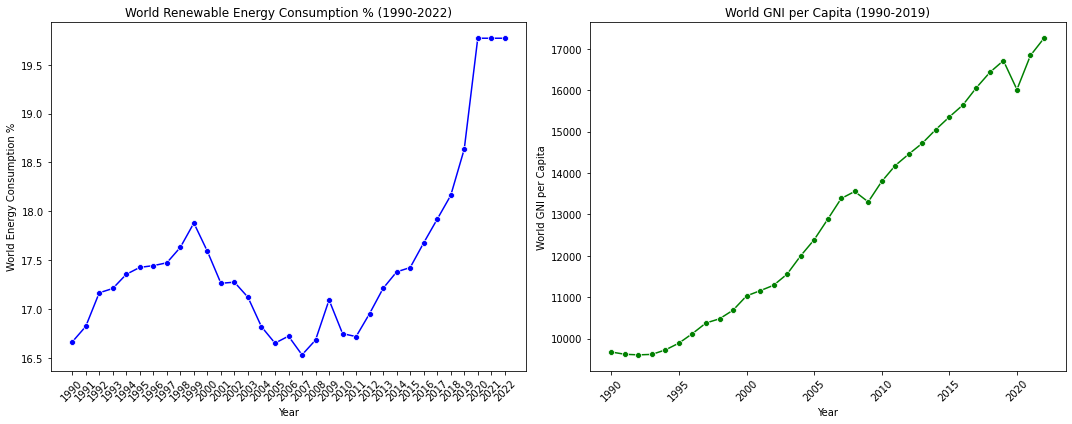

In [15]:
# Prepare data for plotting
energy_consumption = df1.loc[df1["Country"]=="World",years1].squeeze()
gni_per_capita = df2.loc[df2["Country"]=="World",years2].squeeze()    

# Create a figure with subplots
plt.figure(figsize=(15, 6))

# Line plot for Renewable Energy Consumption %
plt.subplot(1, 2, 1)
sns.lineplot(x=energy_consumption.index, y=energy_consumption.values, marker='o', color='blue')
plt.title('World Renewable Energy Consumption % (1990-2022)')
plt.xlabel('Year')
plt.ylabel('World Energy Consumption %')
plt.xticks(rotation=45)

# Line plot for GNI per Capita
plt.subplot(1, 2, 2)
sns.lineplot(x=gni_per_capita.index, y=gni_per_capita.values, marker='o', color='green')
plt.title('World GNI per Capita (1990-2019)')
plt.xlabel('Year')
plt.ylabel('World GNI per Capita')
plt.xticks(rotation=45)

# Adjust layout
plt.tight_layout()
plt.show()

## 2 - Scatter plot

A scatter plot is created in order to visually assess a potential correlation between the two indexes

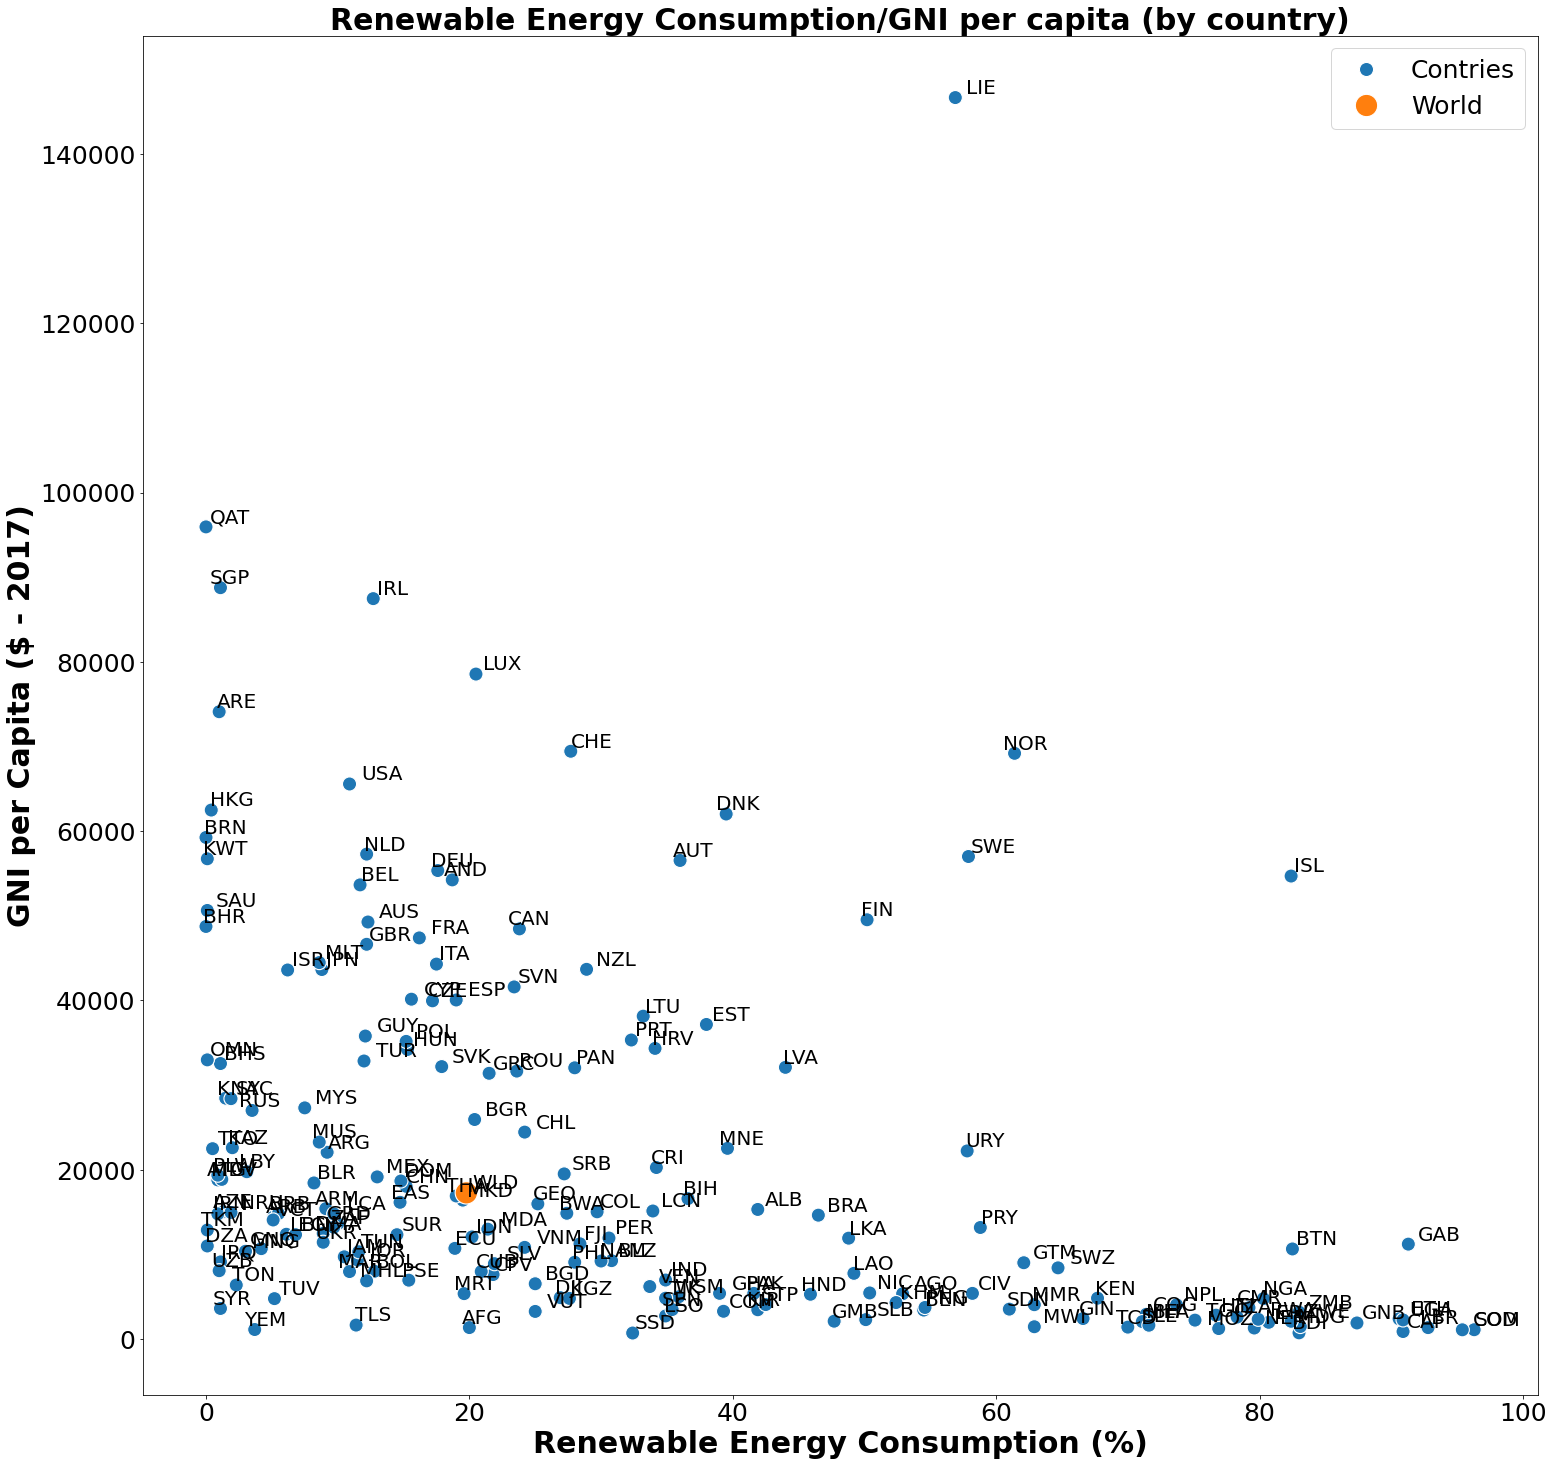

In [16]:

#Make a dataframe with the needed values
countries = df1["Country Code"].values
energy_consumption = df1["2022"].values
gni_per_capita = df2[2022].values

scatter = pd.DataFrame({
    'countries': countries,
    'energy consumption': energy_consumption,
    'GNI per capita': gni_per_capita
})

#Add acolumn to highlight the wotrld bubble in the scatter plot
scatter["Highlight"] = ['World' if cond else 'Contries' for cond in scatter["countries"]=="WLD"]

#Plot the figure
plt.figure(figsize=(25, 25))
sns.scatterplot(data=scatter,x="energy consumption",y="GNI per capita",hue="Highlight",size="Highlight",sizes=(500,200))

for i in range(scatter.shape[0]):
    offset_x = np.random.uniform(-1, 1)  # Random horizontal offset
    offset_y = np.random.uniform(-1, 1)  # Random vertical offset
    plt.text(x=scatter['energy consumption'].iloc[i] + offset_x,
             y=scatter['GNI per capita'].iloc[i] + offset_y,
             s=scatter['countries'].iloc[i],
             fontdict=dict(color='black', size=20),
             ha='left', va='bottom')  # Center the labels over points

plt.title('Renewable Energy Consumption/GNI per capita (by country)', size=30, fontweight="bold")
plt.xlabel('Renewable Energy Consumption (%)', size = 30, fontweight="bold")
plt.ylabel('GNI per Capita ($ - 2017)', size=30, fontweight="bold")
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.legend(fontsize=25)

plt.show()

## 3 - Countries with 0% renewables

As mentioned in Section 4, many countries have 0% renewables: a bar plot is made to assess how many there were each year.

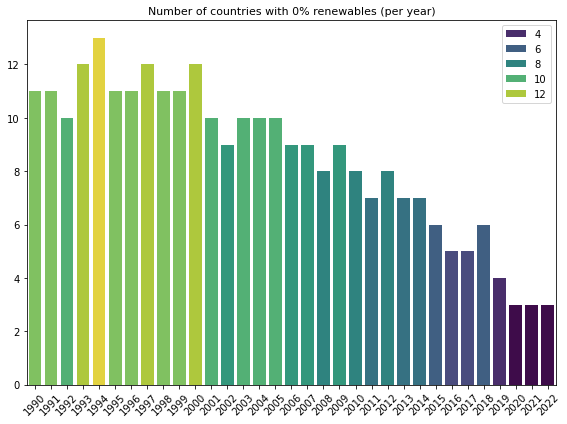

In [17]:
#Create an array with each year's total amount of countries with 0%
count_zeros=[]
for i in years1:
    count_zeros.append(df1.loc[df1[i]==0,:].shape[0])

plt.figure(figsize=(8, 6))
sns.barplot(x=years2, y=count_zeros, hue=count_zeros, palette='viridis', dodge=False)


plt.title('Number of countries with 0% renewables (per year)', size=11, fontweight="regular")
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

## 4 - Top 5 (Renewables % index)

In order to assess which coountries had the highest share of renewable energy consumption in the first and last years of the analysis, two bar plots were made.
The color of the bars vary according to the GNI per capita of the country in order to assess differences in top performers wealth.

NOTE: the subplots are displayed vertically for better visualization of x axis labels

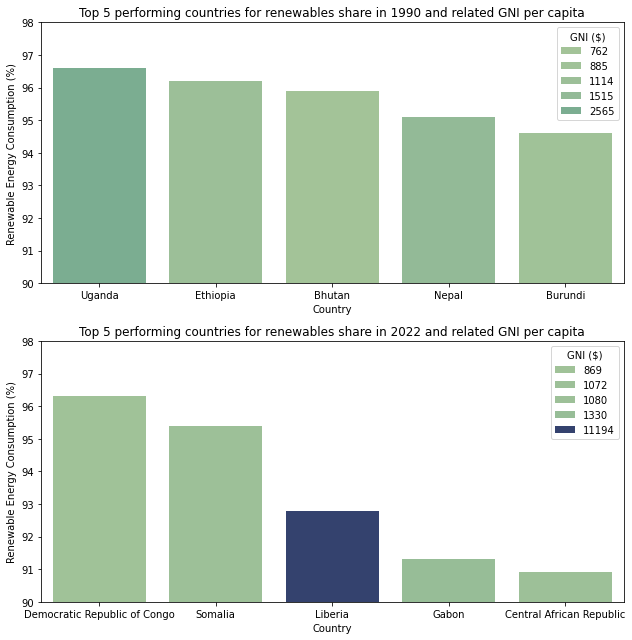

In [18]:

#create figure
plt.figure(figsize=(9, 9))

#Subplot 2 for 1990 barplot
plt.subplot(2, 1, 1)
top_5_1990 = df1.loc[df1["1990"].nlargest(5).index,["Country","1990"]]
gni_5_1990 = df2.loc[df2["Country"].isin(top_5_1990["Country"]),1990]
top_5_1990["GNI ($)"] = gni_5_1990.values.astype(int)  # Add GNI as a new column for hue
sns.barplot(x=top_5_1990["Country"], y=top_5_1990["1990"],palette="crest", hue=top_5_1990["GNI ($)"],hue_norm=(500,12000))

#Subplot 1 style
plt.title('Top 5 performing countries for renewables share in 1990 and related GNI per capita', size=12)
plt.ylabel('Renewable Energy Consumption (%)', size = 10)
plt.xticks(fontsize=10)
plt.ylim(90,98)

#Subplot 2 for 2022 barplot
plt.subplot(2, 1, 2)
top_5_2022 = df1.loc[df1["2022"].nlargest(5).index,["Country","2022"]]
gni_5_2022 = df2.loc[df2["Country"].isin(top_5_2022["Country"]),2022]
top_5_2022["GNI ($)"] = gni_5_2022.values.astype(int)  # Add GNI as a new column for hue
sns.barplot(x=top_5_2022["Country"],y=top_5_2022["2022"], palette="crest", hue=top_5_2022["GNI ($)"], hue_norm=(500,12000))

#Subplot 2 style
plt.title('Top 5 performing countries for renewables share in 2022 and related GNI per capita', size=12)
plt.ylabel('Renewable Energy Consumption (%)', size = 10)
plt.xticks(fontsize=10)
plt.ylim(90,98)

# Adjust layout
plt.tight_layout()
plt.show()

## 5 - World map visualizations

To better visualise the global situation four interactive maps were created:
- GNI per capita in 1990
- GNI per capita in 2022
- Renewable energy consumption (%) in 1990
- Renewable energy consumption (%) in 2022

NOTE: according to the notebook tool used, visualization can change. If map isn't visualized properly, pleas change pio.renders.default value to 'notebook'.

In [19]:
#Import libraries for map plotting
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# import plotly.io as pio
import plotly.io as pio
pio.renderers.default = 'iframe'
#pio.renderers.default = 'notebook'

In [20]:

#Interactive map 1 - GNI per capita in 1990

#Select data for the map plot and make a dataframe
country = df2['Country'].values
country_code = df1['Country Code'].values
year_1990 = df2[1990].values
combined_df = pd.DataFrame({'Country': country, 1990: year_1990, 'Country Code': country_code})


# Create the choropleth map
fig = go.Figure(data=go.Choropleth(
    locations = combined_df['Country Code'],       # Use the correct column for country codes
    z = combined_df[1990],                # Use the correct column for GDP data
    text = combined_df['Country'],         # Use the correct column for country names
    colorscale = 'Blues',
    autocolorscale=False,
    reversescale=True,
    marker_line_color='darkgray',
    marker_line_width=0.5,
    colorbar_tickprefix = '$',
    colorbar_title = 'GNI<br> US$',
))


# Update the layout for the map
fig.update_layout(
    title_text='1990 Global GNI per capita',
    geo=dict(
        showframe=False,
        showcoastlines=False,
        projection_type='equirectangular'
    ),
    annotations = [dict(
        x=0.55,
        y=0.1,
        xref='paper',
        yref='paper',
        text='Source: <a href="https://ourworldindata.org/grapher/gross-national-income-per-capita-undp">\
            Our world in data</a>',
        showarrow = False
    )]
)

fig.show()


In [21]:


#Interactive map 2 - GNI per capita in 2022

#Select data for the map plot and make a dataframe
country = df2['Country'].values
country_code = df1['Country Code'].values
year_2022 = df2[2022].values
combined_df = pd.DataFrame({'Country': country, 2022: year_2022, 'Country Code': country_code})


# Create the choropleth map
fig = go.Figure(data=go.Choropleth(
    locations = combined_df['Country Code'],       # Use the correct column for country codes
    z = combined_df[2022],                # Use the correct column for GDP data
    text = combined_df['Country'],         # Use the correct column for country names
    colorscale = 'Blues',
    autocolorscale=False,
    reversescale=True,
    marker_line_color='darkgray',
    marker_line_width=0.5,
    colorbar_tickprefix = '$',
    colorbar_title = 'GNI<br> US$',
))


# Update the layout for the map
fig.update_layout(
    title_text='2022 Global GNI per capita',
    geo=dict(
        showframe=False,
        showcoastlines=False,
        projection_type='equirectangular'
    ),
    annotations = [dict(
        x=0.55,
        y=0.1,
        xref='paper',
        yref='paper',
        text='Source: <a href="https://ourworldindata.org/grapher/gross-national-income-per-capita-undp">\
            Our world in data</a>',
        showarrow = False
    )]
)

fig.show()


In [22]:
#Interactive map 3 - Renewable energy consumption (%) in 1990

#Select data for the map plot and make a dataframe
selected_columns = df1[['Country', '1990', 'Country Code']]
df_1990 = selected_columns


# Create the choropleth map
fig = go.Figure(data=go.Choropleth(
    locations = df_1990['Country Code'],       # Use the correct column for country codes
    z = df_1990['1990'],                # Use the correct column for GDP data
    text = df_1990['Country'],         # Use the correct column for country names
    colorscale = 'Blues',
    autocolorscale=False,
    reversescale=True,
    marker_line_color='darkgray',
    marker_line_width=0.5,
    colorbar_tickprefix = '%',
    colorbar_title = 'Renewable energy consumption (%)',
))

# Update the layout for the map
fig.update_layout(
    title_text='1990 Renewable energy consumption',
    geo=dict(
        showframe=False,
        showcoastlines=False,
        projection_type='equirectangular'
    ),
    annotations = [dict(
        x=0.55,
        y=0.1,
        xref='paper',
        yref='paper',
        text='Source: <a href="https://data.worldbank.org/indicator/EG.FEC.RNEW.ZS">\
            Data worldbank</a>',
        showarrow = False
    )]
)

fig.show()


In [23]:

#Interactive map 4 - Renewable energy consumption (%) in 2022

#Select data for the map plot and make a dataframe
df_2022 = df1[['Country', '2022', 'Country Code']]

# Create the choropleth map
fig = go.Figure(data=go.Choropleth(
    locations = df_2022['Country Code'],       # Use the correct column for country codes
    z = df_2022['2022'],                # Use the correct column for GDP data
    text = df_2022['Country'],         # Use the correct column for country names
    colorscale = 'Blues',
    autocolorscale=False,
    reversescale=True,
    marker_line_color='darkgray',
    marker_line_width=0.5,
    colorbar_tickprefix = '%',
    colorbar_title = 'Renewable energy consumption (%)',
))



# Update the layout for the map
fig.update_layout(
    title_text='2022 Renewable energy consumption',
    geo=dict(
        showframe=False,
        showcoastlines=False,
        projection_type='equirectangular'
    ),
    annotations = [dict(
        x=0.55,
        y=0.1,
        xref='paper',
        yref='paper',
        text='Source: <a href="https://data.worldbank.org/indicator/EG.FEC.RNEW.ZS">\
            Data worldbank</a>',
        showarrow = False
    )]
)

fig.show()


## 6 - Machine Learning

To answer the last research question: "Is the GNI per capita of the country a good estimator for predicting the percentage of renewable energy consumption of a country?". A linear regression machine learning model is be used.

Firstly, only a linear regression is performed on the renewable energy dataset, later the GNI is used as an estimator for renewable energy consumption.

In [24]:
# STEP 1 - Merging the two datasets together

# first drop the column 'Country Code' to make both datasets compatible
df1_2 = df1.drop ('Country Code', axis = 1)

# Melt df1 (renewable consumption) by country and year
renewable_melted = df1_2.melt(id_vars=['Country'], var_name='Year', value_name='RenewableEnergy')

# Melt df2 (GNI) by country and year
GNI_melted = df2.melt(id_vars=['Country'], var_name='Year', value_name='GNI')

# Before merging, the column 'Year' needs to be converted to an integer
renewable_melted['Year'] = renewable_melted['Year'].astype(int)
GNI_melted['Year'] = GNI_melted['Year'].astype(int)

# Merge the datasets on Country and Year
combined_df = pd.merge(GNI_melted, renewable_melted, on=['Country', 'Year'], how='inner')

In [25]:
# As I'm not using GNI to predict, I'm making a new dataset only with Renewable energy data
renewable_data = combined_df[['Country', 'Year', 'RenewableEnergy']]

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


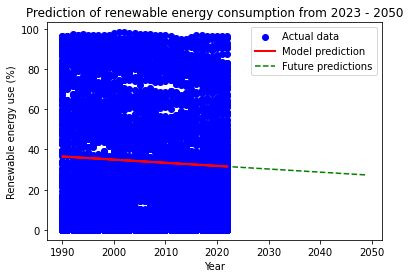

In [27]:
# STEP 2 - linear regression only for renewable energy consumption with all the data
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Select the X = Year and the y = renewable energy
X = renewable_data[['Year']]
y = renewable_data['RenewableEnergy'] 

# Split the data into training and test sets. We chose 80% trainingsdata and 20% testdata
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict renewable energy
y_pred = model.predict(X_test)

# we are interested in the years 2023 - 2050, so we make a dataframe
future_years = pd.DataFrame({'Year': np.arange(2023,2050)}) 
future_predictions = model.predict(future_years)

#plotting
plt.scatter(X, y, color='blue', label='Actual data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Model prediction')
#plt.scatter(X_test, y_pred, color='red', label='Model prediction')  # Use scatter for test predictions
plt.plot (future_years ['Year'], future_predictions, color = 'green', linestyle = '--', label = 'Future predictions')
plt.xlabel('Year')
plt.ylabel('Renewable energy use (%)')
plt.title('Prediction of renewable energy consumption from 2023 - 2050')
plt.legend()
plt.show()

# Make the plot
#plt.scatter(X, y, color='blue', label='Actual data')
#plt.scatter(X_test, y_pred, color='red', label='Model prediction')  # Use scatter for test predictions
#plt.plot(future_years['Year'], future_predictions, color='green', linestyle='--', label='Future predictions')
#plt.xlabel('Year')
#plt.ylabel('Renewable energy use (%)')
#plt.title('Prediction of Renewable Energy Consumption from 2023 to 2050')
#plt.legend()
#plt.show()


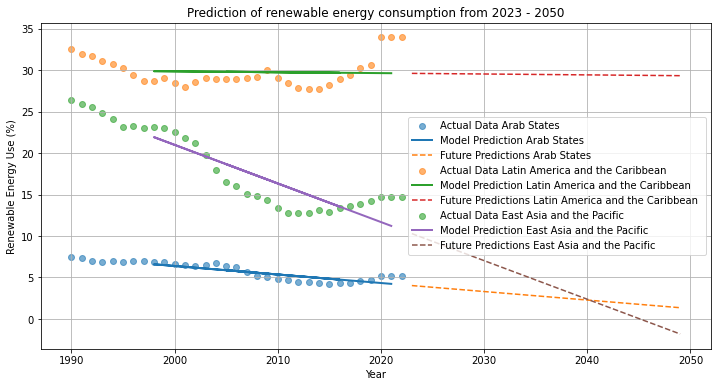

In [28]:
# STEP 3 - As can be seen in the graph, it is not very insightful, so let's focus on a few regions

# make a list of the regions we want to examine
countries = ['Arab States ', 'Latin America and the Caribbean ', 'East Asia and the Pacific ']

future_predictions_all = []

# Create a figure
plt.figure(figsize=(12, 6))

# loop over every country/region and get the data for that country (further we do exacly the same as above)
for country in countries:
    country_data = renewable_data[renewable_data['Country'] == country]
    
    X = country_data[['Year']]  
    y = country_data['RenewableEnergy']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    future_years = pd.DataFrame({'Year': np.arange(2023, 2050)})
    future_predictions = model.predict(future_years)

    future_predictions_df = pd.DataFrame({
        'Region': country,
        'Year': future_years['Year'],
        'Predicted Renewable Energy': future_predictions
    })
    future_predictions_all.append(future_predictions_df)

    plt.scatter(X, y, label=f'Actual Data {country}', alpha=0.6)
    plt.plot(X_test, y_pred, label=f'Model Prediction {country}', linewidth=2)
    plt.plot(future_years['Year'], future_predictions, linestyle='--', label=f'Future Predictions {country}')

plt.xlabel('Year')
plt.ylabel('Renewable Energy Use (%)')
plt.title('Prediction of renewable energy consumption from 2023 - 2050')
plt.legend()
plt.grid()
plt.show()

In [30]:
# STEP 4 - Model validation to estimate how effective it is. We used holdout sets (50%, 50%)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

for country in countries:
    country_data = renewable_data[renewable_data['Country'] == country] 
    
    X = country_data[['Year']]  # Example feature
    y = country_data['RenewableEnergy']
    
# Split the data into training and test sets (50% train, 50% test)
    X1, X2, y1, y2 = train_test_split(X, y, random_state=0, train_size=0.5)

        # Scale the features
    scaler = StandardScaler()
    X1_scaled = scaler.fit_transform(X1)  # Fit on training data
    X2_scaled = scaler.transform(X2)      # Transform test data

    
    # Create and train the linear regression model
    model = LinearRegression()
    model.fit(X1_scaled, y1)
    
    # Print the sizes of the train and test sets
    print(f"Train size for {country}: {round(len(X1) / len(X) * 100)}% \n\
Test size for {country}: {round(len(X2) / len(X) * 100)}%")
    
    # Predict renewable energy use for the test set
    y2_model = model.predict(X2_scaled)

    # Evaluate the model (calculate Mean Squared Error)
    mse = mean_squared_error(y2, y2_model)
    print(f"Mean Squared Error for {country}: {mse:.2f}")

Train size for Arab States : 48% 
Test size for Arab States : 52%
Mean Squared Error for Arab States : 0.25
Train size for Latin America and the Caribbean : 48% 
Test size for Latin America and the Caribbean : 52%
Mean Squared Error for Latin America and the Caribbean : 3.80
Train size for East Asia and the Pacific : 48% 
Test size for East Asia and the Pacific : 52%
Mean Squared Error for East Asia and the Pacific : 4.18


In [33]:
# STEP 5 - Now we will use the GNI as predictor of the renewable energy consumption.

#Use the GNI and renewable energy from the data set
X = combined_df[['GNI']]  
y = combined_df['RenewableEnergy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler() # we used the scaler for this, but this has no difference without it
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_energy = LinearRegression()
model_energy.fit(X_train_scaled, y_train)

y_pred_test = model_energy.predict(X_test_scaled)


/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



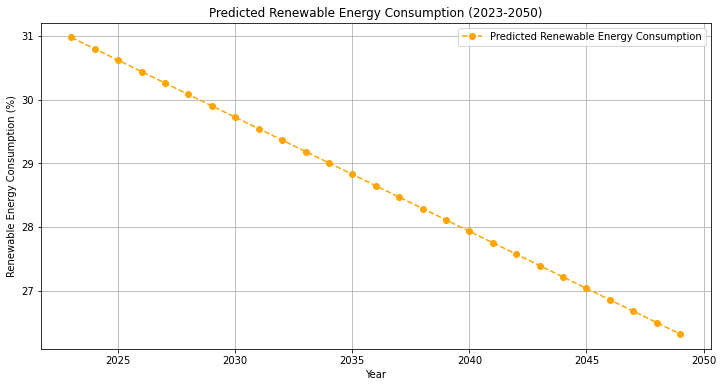

In [36]:
#STEP 5.1 : We first need to predict the GNI with linear regression for the coming years
# so we will use the same steps, we first used for the renewable energy
X_gni = combined_df[['Year']]
y_gni = combined_df['GNI']

X_train_gni, X_test_gni, y_train_gni, y_test_gni = train_test_split(X_gni, y_gni, test_size=0.2, random_state=42)

model_gni = LinearRegression()
model_gni.fit(X_train_gni, y_train_gni)

future_years = pd.DataFrame({'Year': range(2023, 2050)})
future_gni_predictions = model_gni.predict(future_years)

future_gni_df = pd.DataFrame({
    'Year': future_years['Year'],
    'Predicted GNI': future_gni_predictions
})

# We now use the predicted GNI values to predict the renewable energy consumption
future_gni_scaled = scaler.transform(np.array(future_gni_df['Predicted GNI']).reshape(-1, 1))


future_energy_predictions = model_energy.predict(future_gni_scaled)

future_predictions_df = pd.DataFrame({
    'Year': future_gni_df['Year'],
    'Predicted Renewable Energy': future_energy_predictions
})

# plot the prediction
plt.figure(figsize=(12, 6))
plt.plot(future_predictions_df['Year'], future_predictions_df['Predicted Renewable Energy'], marker='o', linestyle='--', color='orange', label='Predicted Renewable Energy Consumption')
plt.title('Predicted Renewable Energy Consumption (2023-2050)')
plt.xlabel('Year')
plt.ylabel('Renewable Energy Consumption (%)')
plt.grid()
plt.legend()
plt.show()

# Section 7: Discussion

Discussion will be made by taking the research questions given in Section 1 and trying to give answers based on the data visualization made in Section 5

## Research questions
- **How does the consumption of renewable energy relate to the Gross National Income (GNI) per capita across different countries**

When looking at plot 2 in the data visualisation section, it can be seen in the scatterplot that there is no clear correlation between GNI per capita and the percentage of reusable energy of the total energy consumption. Quatar for example, has a high GNI per capita but uses no reusable energy. On the other side, Gabon has a low GNI and has a high percentage of reusable energy. All the other countries are somewhere in between. No clear trend line can be drawn between all the dots. In conclusion, there is no clear relation between the two.

- **How have the two indexes evolved over the last 32 years and how similar the trajectories are**

**First index:** The renewable energy consumption fluctuates a lot. There is an initial peak at 1997 of a lot of durable energy. In 1997 the Kyoto protocol countries agreed to reduce greenhouse gas emissions during 2008 and 2012 with 5,2% comparing to 1990. 55 countries joined in on this treaty. It is curious that the percentage of renewable energy consumption did not increase, instead it dropped after this. Only in 2008 there was a peak. This is probably due to the financial crisis in 2008 that caused for factories to close. After that in 2015 the Paris agreement of 2015 was negotiated. The goal of this treaty was to keep the global temperature from rising more that 1.5 degrees Celsius. In order to reach this goal these countries agreed to cut the carbon emissions 50% by 2030 and to be carbon neutral in 2050. In the graph a clear increase of renewable energy consumption can be seen as a result of this treaty.
**Second Iindex:** The GNI per capita is almost a linear growth. Except for the small drop in 2008, due to the financial crisis and a drop in 2020 due to the covid pandemic. 

In conclusion, both graphs show an overall ascending trajectories but GNI index is much more linear then the other.

- **Are there still countries that have no share of renewables in their energy consumption and, if so, are they decreasing in number**

In 2022 there still were three countries that had no share of renewable energy consumption. This number had a gradual decrease from 1990. T§he peak, though, was reached in 1994 with 13 countries without a share of renewable energy.

- **What are the countries that have the highest share of energy consumption coming from renewables and how high is their GNI**

Top 5 Countries for renewable energy consumption in 1990 are Asian and African countries. Their GDP is low compared to the world's, which at the time amounted to roughly 9678 dollars. Even if general situation for renewables energy consumption increased, top 5 performers in 2022 (all african countries) show on average worse performances than in 1990. Moreover, their GNI is on the same levels of 1990 and much lower than the world's 17254 dollars of that year, except for Liberia that has a GNI per capita of 11194 dollars in 2022.
To sum up, top performers come from poor countries, they currently are all from Africa and their GNI is getting much lower than the world's.

- **Regarding areas with lower GNI, how can we expect their situation to vary in the future for both indexes**

In general, the GNI of a country grows overtime because they acquire more wealth over the years. This can also be seen in the mean GNI of the world over time. The renewable energy consumption however, is not very predictable. Not all the countries have signed the Paris Agreement, this means that they will not all try to reduce their greenhouse gas emissions. 
- **Is the GNI per capita of the country a good estimator for predicting the percentage of renewable energy consumption of a country**

To answer this last question a linear regression model was used. As already seen before, the GNI was not a good predictor and also from this analysis this became clear. If GNI is used as a predictor, the renewable energy use would only lower, and hopefully that is not the case for the coming years. This is probably due to the fact that there are quite some countries with a very low GNI that hava a relatively large share of renewable energy.*

## Assesments and Limitations

Gross National Income (GNI) represents the total value produced by a country's economy, including the income received by its citizens and foreign aid. While GNI includes Gross Domestic Product (GDP) and serves as a useful measure of overall economic activity, it has some limitations. For instance, GNI can be misleading because it does not account for the population size of a country. Additionally, it does not provide insight into the quality of life within that nation. Comparing GNI figures across countries can also be challenging due to fluctuations in currency exchange rates, which may distort the GNI values of some nations (Maverick, J.B., 2023).

Another important issue is the data from the World Bank. For example, the World Bank states that Somalia had a renewable energy consumption rate of 95.4% in 2022. However, according to Our World in Data, the share of electricity generated from renewable sources in Somalia is only 10.53%, with fossil fuels making up 89.5%. This significant discrepancy raises questions about wether the index provided by the World Bank was the best choice for this analysis (Roser, H., 2023).

In analyzing the data, some gaps were filled using linear interpolation and backward and forward filling. While this method can be somewhat effective, it cannot guarantee the exact values for those years, potentially leading to slight discrepancies.

In the machine learning aspect of the study, linear regression was used to predict that countries can still meet their climate goals, which could enable a faster transition to renewable energy consumption. Further research could explore various areas, such as the relationship between the percentage of the population with access to electricity and the share of renewable energy used. Additionally, the impact of GNI growth on the percentage of renewable energy consumption could be investigated.

# Section 8: Conclusion

To conclude, the analysis revealed that there is no clear correlation between the GNI and the renewable energy consumption. We can see that there are some countries with a relatively low GNI, have a high share of renewable energy, but this is explainable with the fact that these countries have low access to electricity in general. In all the other countries it is not possible to see a trend. Over the last 32 years, while the GNI showed a linear growth, the renewable energy consumption fluctuated a lot due to global events and agreements.

Despite the Kyoto Protocol, the share of renewable energy consumption did not increase. However, Paris Agreement, did make the renewable energy consumption rise. It is still unsure if we are going to reach the goal of the agreement.
This analysis couldn’t predict this as there are many more factors playing a role in the renewable energy consumption beyond the GNI. 